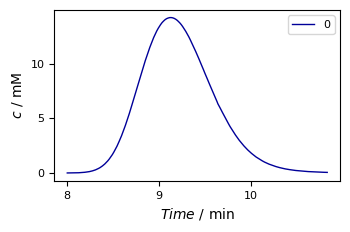

In [1]:
import numpy as np
data = np.loadtxt('experimental_data/pore_penetrating_tracer.csv', delimiter=',')

time_experiment = data[:, 0]
c_experiment = data[:, 1]

from CADETProcess.reference import ReferenceIO
tracer_peak = ReferenceIO(
    'Tracer Peak', time_experiment, c_experiment
)

if __name__ == '__main__':
    _ = tracer_peak.plot()

In [2]:
from CADETProcess.processModel import ComponentSystem
component_system = ComponentSystem(['Penetrating Tracer'])

In [3]:
from CADETProcess.processModel import Inlet, Outlet, LumpedRateModelWithPores

feed = Inlet(component_system, name='feed')
feed.c = [131.75]

eluent = Inlet(component_system, name='eluent')
eluent.c = [0]

column = LumpedRateModelWithPores(component_system, name='column')

column.length = 0.1
column.diameter = 0.0077
column.particle_radius = 34e-6

column.axial_dispersion = 1e-8
column.bed_porosity = 0.3
column.particle_porosity = 0.8

column.film_diffusion = [1]

outlet = Outlet(component_system, name='outlet')

In [4]:
from CADETProcess.processModel import FlowSheet

flow_sheet = FlowSheet(component_system)

flow_sheet.add_unit(feed)
flow_sheet.add_unit(eluent)
flow_sheet.add_unit(column)
flow_sheet.add_unit(outlet)

flow_sheet.add_connection(feed, column)
flow_sheet.add_connection(eluent, column)
flow_sheet.add_connection(column, outlet)

In [5]:
from CADETProcess.processModel import Process

Q_ml_min = 0.5  # ml/min
Q_m3_s = Q_ml_min / (60 * 1e6)
V_tracer = 50e-9  # m3

process = Process(flow_sheet, 'Tracer')
process.cycle_time = 15 * 60

process.add_event(
    'feed_on',
    'flow_sheet.feed.flow_rate',
    Q_m3_s, 0
)
process.add_event(
    'feed_off',
    'flow_sheet.feed.flow_rate',
    0,
    V_tracer / Q_m3_s
)

process.add_event(
    'feed_water_on',
    'flow_sheet.eluent.flow_rate',
     Q_m3_s,
     V_tracer / Q_m3_s
)

process.add_event(
    'eluent_off',
    'flow_sheet.eluent.flow_rate',
    0,
    process.cycle_time
)

Event(name=eluent_off, parameter_path=flow_sheet.eluent.flow_rate, state=0, time=0.0, indices=[(slice(None, None, None),)])

In [6]:
from CADETProcess.simulator import Cadet
simulator = Cadet()

if __name__ == '__main__':
    simulation_results = simulator.simulate(process)
    _ = simulation_results.solution.outlet.inlet.plot()

In [7]:
from CADETProcess.comparison import Comparator

comparator = Comparator()
comparator.add_reference(tracer_peak)
comparator.add_difference_metric(
    'NRMSE', tracer_peak, 'outlet.outlet',
)

if __name__ == '__main__':
    comparator.plot_comparison(simulation_results)

C:\Users\ezeiry\AppData\Local\Temp\ipykernel_38664\2004803981.py:4: DeprecationWarning: add_reference() is deprecated and will be removed in v1.0. Pass a pre-constructed metric instance to add_difference_metric() instead: metric = SSE(reference); comparator.add_difference_metric(metric, solution_path)
  comparator.add_reference(tracer_peak)
C:\Users\ezeiry\AppData\Local\Temp\ipykernel_38664\2004803981.py:5: DeprecationWarning: Passing a metric class name as a string to add_difference_metric() is deprecated and will be removed in v1.0. Construct the metric directly and pass the instance instead: metric = SSE(reference); comparator.add_difference_metric(metric, solution_path)
  comparator.add_difference_metric(


In [8]:
from CADETProcess.optimization import OptimizationProblem

optimization_problem = OptimizationProblem('particle_porosity')

optimization_problem.add_evaluation_object(process)

optimization_problem.add_variable(
    name='particle_porosity',
    parameter_path='flow_sheet.column.particle_porosity',
    lb=0.5, ub=0.99,
    transform='auto'
)

optimization_problem.add_evaluator(simulator)

optimization_problem.add_objective(
    comparator,
    n_objectives=comparator.n_metrics,
    requires=[simulator]
)


def callback(simulation_results, individual, evaluation_object, callbacks_dir='./'):
    comparator.plot_comparison(
        simulation_results,
        file_name=f'{callbacks_dir}/{individual.id}_{evaluation_object}_comparison.png',
        show=False
    )


optimization_problem.add_callback(callback, requires=[simulator])

[INFO 08-12 16:15:11] ax.storage.sqa_store.with_db_settings_base: Ax SQL storage initialized with SQLAlchemy 2.0.52


In [9]:
from CADETProcess.optimization import U_NSGA3
optimizer = U_NSGA3()